 # CS466 Final Project: Multimodal Affect Recognition for Online Learning
 ## Check-In 1

 **Author: Rui Wu**
 **CS466**
 **Date:** 03.15.2026

 ## 1. Setup and Imports

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
 
# MediaPipe setup -- handles both old (<=0.10.14) and new (>=0.10.30) APIs
MEDIAPIPE_LEGACY = False   # True = mp.solutions API (old)
MEDIAPIPE_TASKS = False    # True = mp.tasks API (new)
 
try:
    import mediapipe as mp
    print(f"MediaPipe version: {mp.__version__}")
    try:
        _test = mp.solutions.face_detection
        MEDIAPIPE_LEGACY = True
        print("  Using legacy mp.solutions API")
    except AttributeError:
        pass

    if not MEDIAPIPE_LEGACY:
        try:
            _test = mp.tasks.vision
            MEDIAPIPE_TASKS = True
            print("  Using new mp.tasks API")
        except AttributeError:
            pass
    
    if not MEDIAPIPE_LEGACY and not MEDIAPIPE_TASKS:
        print("  WARNING: Neither API available. Using OpenCV fallback.")
except ImportError:
    print("MediaPipe not installed. Using OpenCV fallback.")
if MEDIAPIPE_TASKS:
    import urllib.request
    
    FACE_DETECTOR_MODEL = "blaze_face_short_range.tflite"
    FACE_LANDMARKER_MODEL = "face_landmarker.task"
    
    if not os.path.exists(FACE_DETECTOR_MODEL):
        print("Downloading face detector model...")
        urllib.request.urlretrieve(
            "https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite",
            FACE_DETECTOR_MODEL
        )
    
    if not os.path.exists(FACE_LANDMARKER_MODEL):
        print("Downloading face landmarker model...")
        urllib.request.urlretrieve(
            "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
            FACE_LANDMARKER_MODEL
        )
 
opencv_face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
 
# Configure paths -- UPDATE THIS to match your local setup
DAISEE_ROOT = "/Users/apple/Desktop/DAiSEE"
DATA_DIR = os.path.join(DAISEE_ROOT, "DataSet")
LABEL_DIR = os.path.join(DAISEE_ROOT, "Labels")
 
# Verify paths exist
for p in [DATA_DIR, LABEL_DIR]:
    if os.path.exists(p):
        print(f"Found: {p}")
    else:
        print(f"NOT FOUND: {p} -- please update the path")

MediaPipe version: 0.10.32
  Using new mp.tasks API
Found: /Users/apple/Desktop/DAiSEE/DataSet
Found: /Users/apple/Desktop/DAiSEE/Labels


 ## 2. Load and Explore Labels

 DAiSEE provides CSV label files for train, validation, and test splits.
 Each row maps a video clip path to four affective state labels (0-3 scale):
 Boredom, Engagement, Confusion, Frustration.

In [ ]:
# Load label CSVs
train_labels = pd.read_csv(os.path.join(LABEL_DIR, "TrainLabels.csv"))
val_labels = pd.read_csv(os.path.join(LABEL_DIR, "ValidationLabels.csv"))
test_labels = pd.read_csv(os.path.join(LABEL_DIR, "TestLabels.csv"))
 
print("=== Dataset Split Sizes ===")
print(f"Train:      {len(train_labels)} snippets")
print(f"Validation: {len(val_labels)} snippets")
print(f"Test:       {len(test_labels)} snippets")
print(f"Total:      {len(train_labels) + len(val_labels) + len(test_labels)} snippets")
 
print("\n=== Column Names ===")
print(train_labels.columns.tolist())
 
print("\n=== Sample Rows (Train) ===")
train_labels.head()

=== Dataset Split Sizes ===
Train:      5358 snippets
Validation: 1429 snippets
Test:       1784 snippets
Total:      8571 snippets

=== Column Names ===
['ClipID', 'Boredom', 'Engagement', 'Confusion', 'Frustration ']

=== Sample Rows (Train) ===


,ClipID,Boredom,Engagement,Confusion,Frustration
0,1100011002.avi,0,2,0,0
1,1100011003.avi,0,2,0,0
2,1100011004.avi,0,3,0,0
3,1100011005.avi,0,3,0,0
4,1100011006.avi,0,3,0,0


 ## 3. Label Distribution Analysis

 Understanding the class distribution is critical since DAiSEE is known to be heavily imbalanced.

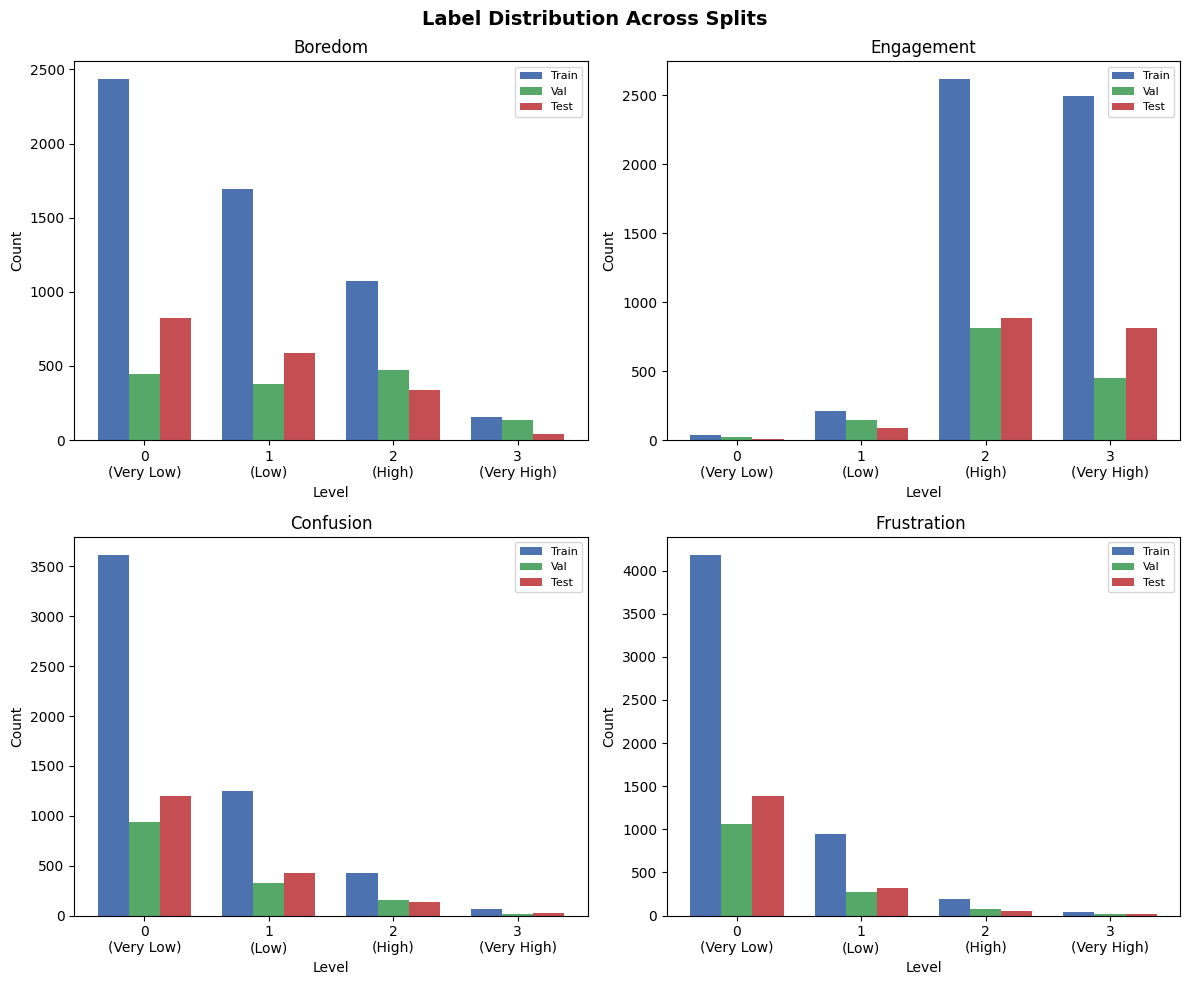


=== Detailed Engagement Distribution ===

Train:
  Level 0 (Very Low): 34 (0.6%)
  Level 1 (Low): 213 (4.0%)
  Level 2 (High): 2617 (48.8%)
  Level 3 (Very High): 2494 (46.5%)

Val:
  Level 0 (Very Low): 23 (1.6%)
  Level 1 (Low): 143 (10.0%)
  Level 2 (High): 813 (56.9%)
  Level 3 (Very High): 450 (31.5%)

Test:
  Level 0 (Very Low): 4 (0.2%)
  Level 1 (Low): 84 (4.7%)
  Level 2 (High): 882 (49.4%)
  Level 3 (Very High): 814 (45.6%)


In [ ]:
affective_states = ["Boredom", "Engagement", "Confusion", "Frustration "]
level_names = {0: "Very Low", 1: "Low", 2: "High", 3: "Very High"}
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Label Distribution Across Splits", fontsize=14, fontweight="bold")
 
for idx, state in enumerate(affective_states):
    ax = axes[idx // 2][idx % 2]
    
    # Count per level for each split
    train_counts = train_labels[state].value_counts().sort_index()
    val_counts = val_labels[state].value_counts().sort_index()
    test_counts = test_labels[state].value_counts().sort_index()
    
    x = np.arange(4)
    width = 0.25
    
    ax.bar(x - width, [train_counts.get(i, 0) for i in range(4)], width, label="Train", color="#4C72B0")
    ax.bar(x, [val_counts.get(i, 0) for i in range(4)], width, label="Val", color="#55A868")
    ax.bar(x + width, [test_counts.get(i, 0) for i in range(4)], width, label="Test", color="#C44E52")
    
    ax.set_title(state, fontsize=12)
    ax.set_xlabel("Level")
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(["0\n(Very Low)", "1\n(Low)", "2\n(High)", "3\n(Very High)"])
    ax.legend(fontsize=8)
 
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("\n=== Detailed Engagement Distribution ===")
for split_name, df in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    counts = df["Engagement"].value_counts().sort_index()
    total = len(df)
    print(f"\n{split_name}:")
    for level in range(4):
        c = counts.get(level, 0)
        print(f"  Level {level} ({level_names[level]}): {c} ({c/total*100:.1f}%)")

 ## 4. Video Loading and Frame Extraction

 Each DAiSEE video is ~10 seconds at 30fps (300 frames).
 We sample T frames uniformly to keep processing manageable.

Raw ClipID from CSV: '1100011002.avi'
Constructed video path: /Users/apple/Desktop/DAiSEE/DataSet/Train/110001/1100011002/1100011002.avi
File exists: True

Video metadata: {'total_frames': 300, 'fps': 30.0, 'width': 640, 'height': 480, 'duration_sec': 10.0}
Extracted 10 frames


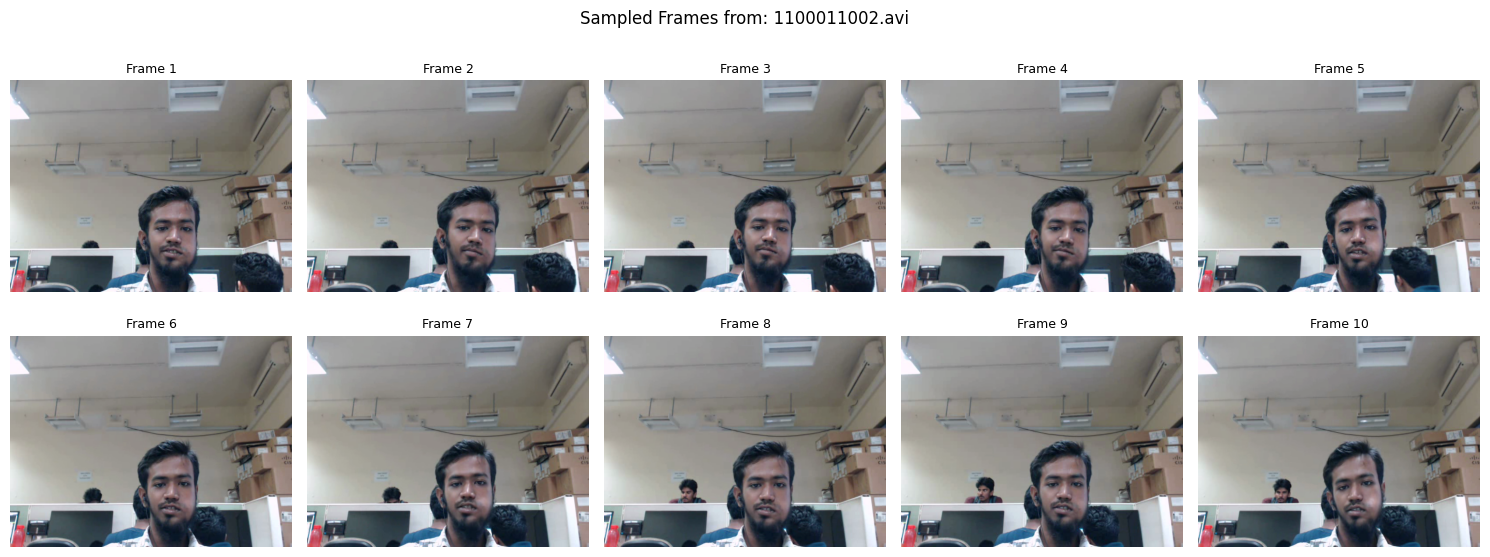

In [ ]:
def get_video_path(clip_id, data_dir, split="Train"):
    """
    Construct the full path to a video file from its label CSV entry.
    
    DAiSEE folder structure: DataSet/Train/SUBJECT_ID/CLIP_ID/CLIP_ID.avi
    Example: DataSet/Train/110001/1100011002/1100011002.avi

    """
    # If clip_id already contains path separators, use it directly
    if "/" in clip_id or "\\" in clip_id:
        return os.path.join(data_dir, split, clip_id)
    
    # Otherwise, reconstruct the nested path from the clip filename
    clip_name = clip_id.replace(".avi", "")
    subject_id = clip_name[:6]
    full_path = os.path.join(data_dir, split, subject_id, clip_name, clip_name + ".avi")
    return full_path
 
 
def extract_frames(video_path, num_frames=10):
    """
    Extract num_frames uniformly spaced frames from a video.
    
    Args:
        video_path: Path to the .avi video file
        num_frames: Number of frames to sample (default: 10)
    
    Returns:
        frames: List of BGR frames as numpy arrays
        metadata: Dict with video properties
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Cannot open {video_path}")
        return [], {}
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    metadata = {
        "total_frames": total_frames,
        "fps": fps,
        "width": width,
        "height": height,
        "duration_sec": total_frames / fps if fps > 0 else 0
    }
    
    # Compute uniform sample indices
    if total_frames <= num_frames:
        indices = list(range(total_frames))
    else:
        indices = np.linspace(0, total_frames - 1, num_frames, dtype=int).tolist()
    
    frames = []
    for frame_idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    
    cap.release()
    return frames, metadata
 
 
# Demo: load one video and extract frames
clip_path = train_labels.iloc[0]["ClipID"]
print(f"Raw ClipID from CSV: '{clip_path}'")
sample_video = get_video_path(clip_path, DATA_DIR, split="Train")
print(f"Constructed video path: {sample_video}")
print(f"File exists: {os.path.exists(sample_video)}")
 
# If path not found, try to discover the actual structure
if not os.path.exists(sample_video):
    train_dir = os.path.join(DATA_DIR, "Train")
    if os.path.exists(train_dir):
        print(f"\nContents of {train_dir} (first 5):")
        contents = sorted(os.listdir(train_dir))[:5]
        for item in contents:
            print(f"  {item}/")
            subpath = os.path.join(train_dir, item)
            if os.path.isdir(subpath):
                sub_contents = sorted(os.listdir(subpath))[:3]
                for sub in sub_contents:
                    print(f"    {sub}/")
                    subsubpath = os.path.join(subpath, sub)
                    if os.path.isdir(subsubpath):
                        files = os.listdir(subsubpath)[:2]
                        for f in files:
                            print(f"      {f}")
        print("\nPlease check the structure above and adjust get_video_path if needed.")
 
if os.path.exists(sample_video):
    frames, meta = extract_frames(sample_video, num_frames=10)
    print(f"\nVideo metadata: {meta}")
    print(f"Extracted {len(frames)} frames")
    
    # Display sampled frames
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(f"Sampled Frames from: {clip_path}", fontsize=12)
    for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        ax.set_title(f"Frame {i+1}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig("sample_frames.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Video not found at: {sample_video}")
    print("Please update DAISEE_ROOT or check get_video_path logic.")

 ## 5. Modality 1: Appearance Features (Face Detection & Cropping)

 We detect faces, crop them, and resize to 224x224 for CNN input.
 Uses MediaPipe (new or legacy API) or OpenCV Haar cascade as fallback.

I0000 00:00:1775621178.220338 26818826 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775621178.222023 26818831 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Face detector: MediaPipe tasks API


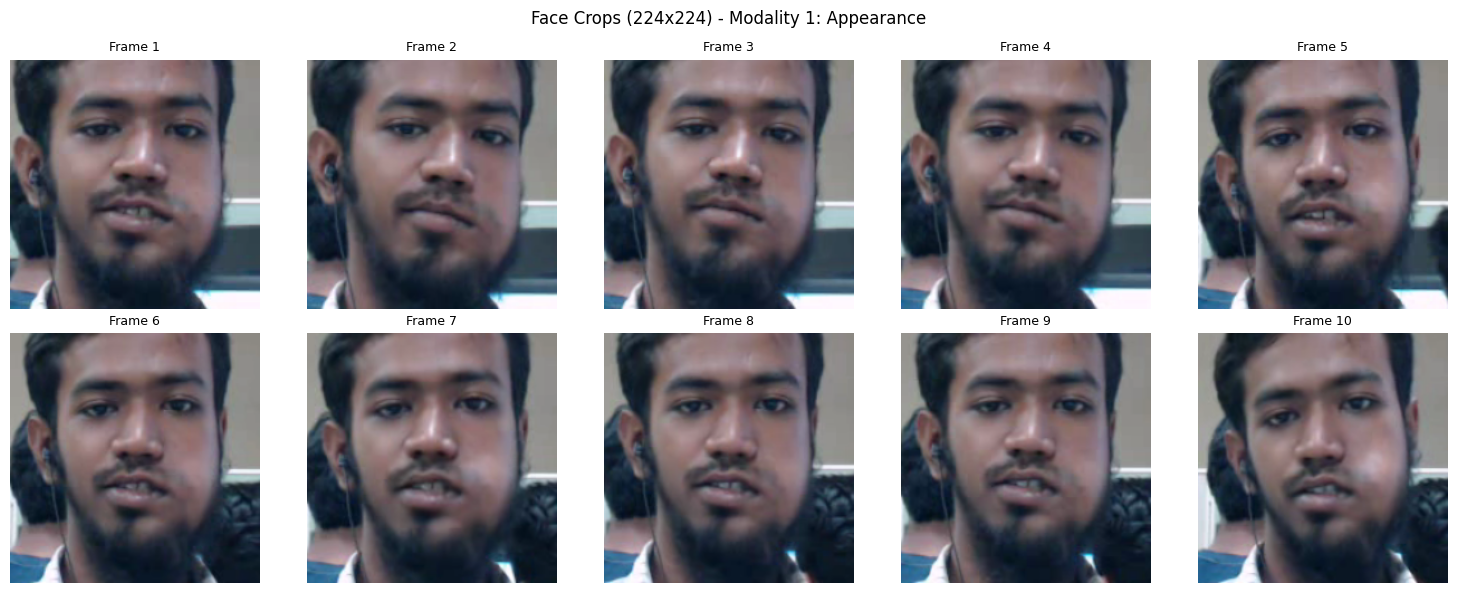

Face detected in 10/10 frames


In [ ]:
def detect_and_crop_face(frame, target_size=(224, 224), padding=0.2,
                         _mp_detector=None):
    """
    Detect and crop the face from a frame.
    Tries: MediaPipe tasks API -> MediaPipe legacy -> OpenCV Haar cascade.
    
    Args:
        frame: BGR image (numpy array)
        target_size: Output crop size (H, W)
        padding: Fractional padding around the detection box
        _mp_detector: (internal) MediaPipe tasks FaceDetector instance
    
    Returns:
        face_crop: Resized face crop (RGB), or None if no face detected
        bbox: (x1, y1, x2, y2) of the detected face, or None
    """
    h, w, _ = frame.shape
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    x1, y1, bw, bh = 0, 0, 0, 0
    detected = False
    
    # Method 1: MediaPipe tasks API (new, >=0.10.30)
    if MEDIAPIPE_TASKS and _mp_detector is not None:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        result = _mp_detector.detect(mp_image)
        if result.detections:
            bbox = result.detections[0].bounding_box
            x1, y1, bw, bh = bbox.origin_x, bbox.origin_y, bbox.width, bbox.height
            detected = True
    
    # Method 2: OpenCV Haar cascade (always available)
    if not detected:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = opencv_face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60)
        )
        if len(faces) > 0:
            x1, y1, bw, bh = faces[0]
            detected = True
    
    if not detected:
        return None, None
    
    # Add padding
    pad_x = int(bw * padding)
    pad_y = int(bh * padding)
    x1_pad = max(0, x1 - pad_x)
    y1_pad = max(0, y1 - pad_y)
    x2 = min(w, x1 + bw + pad_x)
    y2 = min(h, y1 + bh + pad_y)
    
    face_crop = rgb_frame[y1_pad:y2, x1_pad:x2]
    
    if face_crop.size == 0:
        return None, None
    
    face_crop = cv2.resize(face_crop, target_size)
    return face_crop, (x1_pad, y1_pad, x2, y2)
 
 
# Create face detector
face_detector = None
if MEDIAPIPE_TASKS:
    BaseOptions = mp.tasks.BaseOptions
    FaceDetector = mp.tasks.vision.FaceDetector
    FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
    VisionRunningMode = mp.tasks.vision.RunningMode
    
    options = FaceDetectorOptions(
        base_options=BaseOptions(model_asset_path=FACE_DETECTOR_MODEL),
        running_mode=VisionRunningMode.IMAGE,
        min_detection_confidence=0.5
    )
    face_detector = FaceDetector.create_from_options(options)
    print("Face detector: MediaPipe tasks API")
else:
    print("Face detector: OpenCV Haar cascade (fallback)")
 
# Demo: detect and crop faces from sample frames
if os.path.exists(sample_video):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle("Face Crops (224x224) - Modality 1: Appearance", fontsize=12)
    
    detected_count = 0
    for i, (ax, frame) in enumerate(zip(axes.flat, frames)):
        crop, bbox = detect_and_crop_face(frame, _mp_detector=face_detector)
        if crop is not None:
            ax.imshow(crop)
            detected_count += 1
        else:
            ax.imshow(np.zeros((224, 224, 3), dtype=np.uint8))
        ax.set_title(f"Frame {i+1}", fontsize=9)
        ax.axis("off")
    
    plt.tight_layout()
    plt.savefig("face_crops.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Face detected in {detected_count}/{len(frames)} frames")

 ## 6. Modality 2: Geometric Features (Facial Landmarks & Head Pose)

 We extract facial landmarks to compute:
 - Head pose (pitch, yaw, roll) via solvePnP
 - Eye Aspect Ratio (EAR) for blink/gaze
 - Mouth Aspect Ratio (MAR)

 Uses MediaPipe FaceLandmarker (new tasks API) if available.

In [ ]:
# Key landmark indices (MediaPipe Face Mesh convention, 478 landmarks)
LEFT_EYE = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33, 160, 158, 133, 153, 144]
MOUTH_OUTER = [61, 291, 0, 17]  # left, right, top, bottom
POSE_LANDMARKS = [1, 33, 263, 61, 291, 199]  # nose, L-eye, R-eye, L-mouth, R-mouth, chin
 
 
def compute_ear(landmarks, eye_indices, w, h):
    """Compute Eye Aspect Ratio from landmark coordinates."""
    pts = [(landmarks[i].x * w, landmarks[i].y * h) for i in eye_indices]
    v1 = np.linalg.norm(np.array(pts[1]) - np.array(pts[5]))
    v2 = np.linalg.norm(np.array(pts[2]) - np.array(pts[4]))
    horiz = np.linalg.norm(np.array(pts[0]) - np.array(pts[3]))
    if horiz == 0:
        return 0.0
    return (v1 + v2) / (2.0 * horiz)
 
 
def compute_mar(landmarks, mouth_indices, w, h):
    """Compute Mouth Aspect Ratio from landmark coordinates."""
    pts = [(landmarks[i].x * w, landmarks[i].y * h) for i in mouth_indices]
    vertical = np.linalg.norm(np.array(pts[2]) - np.array(pts[3]))
    horiz = np.linalg.norm(np.array(pts[0]) - np.array(pts[1]))
    if horiz == 0:
        return 0.0
    return vertical / horiz
 
 
def estimate_head_pose(landmarks, w, h):
    """Estimate head pose (pitch, yaw, roll) using solvePnP."""
    model_points = np.array([
        (0.0, 0.0, 0.0),
        (-225.0, 170.0, -135.0),
        (225.0, 170.0, -135.0),
        (-150.0, -150.0, -125.0),
        (150.0, -150.0, -125.0),
        (0.0, -330.0, -65.0)
    ], dtype=np.float64)
    
    image_points = np.array([
        (landmarks[idx].x * w, landmarks[idx].y * h) for idx in POSE_LANDMARKS
    ], dtype=np.float64)
    
    focal_length = w
    center = (w / 2, h / 2)
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype=np.float64)
    
    dist_coeffs = np.zeros((4, 1))
    success, rotation_vec, translation_vec = cv2.solvePnP(
        model_points, image_points, camera_matrix, dist_coeffs,
        flags=cv2.SOLVEPNP_ITERATIVE
    )
    
    if not success:
        return None
    
    rotation_mat, _ = cv2.Rodrigues(rotation_vec)
    pose_mat = np.hstack([rotation_mat, translation_vec])
    _, _, _, _, _, _, euler_angles = cv2.decomposeProjectionMatrix(
        np.vstack([pose_mat, [0, 0, 0, 1]])[:3, :]
    )
    
    pitch, yaw, roll = euler_angles.flatten()[:3]
    return (pitch, yaw, roll)
 
 
def extract_geometric_features(frame, landmarker=None):
    """
    Extract geometric features from a single frame.
    
    Args:
        frame: BGR image
        landmarker: MediaPipe FaceLandmarker instance (new API), or None
    
    Returns:
        features dict, or None if no face detected
    """
    h, w, _ = frame.shape
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    landmarks = None
    
    if MEDIAPIPE_TASKS and landmarker is not None:
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        result = landmarker.detect(mp_image)
        if result.face_landmarks:
            landmarks = result.face_landmarks[0]
    
    if landmarks is None:
        return None
    
    left_ear = compute_ear(landmarks, LEFT_EYE, w, h)
    right_ear = compute_ear(landmarks, RIGHT_EYE, w, h)
    mar = compute_mar(landmarks, MOUTH_OUTER, w, h)
    pose = estimate_head_pose(landmarks, w, h)
    
    return {
        "head_pose": pose,
        "left_ear": left_ear,
        "right_ear": right_ear,
        "mar": mar,
        "num_landmarks": len(landmarks)
    }
 
 
# Create face landmarker
face_landmarker = None
if MEDIAPIPE_TASKS:
    FaceLandmarker = mp.tasks.vision.FaceLandmarker
    FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
    
    lm_options = FaceLandmarkerOptions(
        base_options=mp.tasks.BaseOptions(model_asset_path=FACE_LANDMARKER_MODEL),
        running_mode=mp.tasks.vision.RunningMode.IMAGE,
        num_faces=1
    )
    face_landmarker = FaceLandmarker.create_from_options(lm_options)
    print("Face landmarker: MediaPipe tasks API")
else:
    print("Face landmarker: Not available (geometric features will use placeholder values)")
    print("  This is fine for Check-In 1 -- full extraction will be done when models are trained.")
 
# Demo: extract geometric features
if os.path.exists(sample_video):
    print("\n=== Geometric Features per Frame ===\n")
    all_features = []
    
    for i, frame in enumerate(frames):
        feats = extract_geometric_features(frame, face_landmarker)
        if feats:
            all_features.append(feats)
            pose = feats["head_pose"]
            pose_str = f"({pose[0]:.1f}, {pose[1]:.1f}, {pose[2]:.1f})" if pose else "N/A"
            print(f"Frame {i+1}: Pose(P,Y,R)={pose_str}  "
                  f"L_EAR={feats['left_ear']:.3f}  "
                  f"R_EAR={feats['right_ear']:.3f}  "
                  f"MAR={feats['mar']:.3f}")
        else:
            print(f"Frame {i+1}: No face/landmarks detected")
    
    print(f"\nGeometric features extracted from {len(all_features)}/{len(frames)} frames")

Face landmarker: MediaPipe tasks API

=== Geometric Features per Frame ===

Frame 1: Pose(P,Y,R)=(165.7, 1.1, 3.5)  L_EAR=0.293  R_EAR=0.239  MAR=0.469
Frame 2: Pose(P,Y,R)=(161.3, -2.9, 8.7)  L_EAR=0.285  R_EAR=0.235  MAR=0.375
Frame 3: Pose(P,Y,R)=(162.6, 2.7, 6.1)  L_EAR=0.291  R_EAR=0.238  MAR=0.357
Frame 4: Pose(P,Y,R)=(165.4, 2.4, 6.9)  L_EAR=0.294  R_EAR=0.245  MAR=0.354
Frame 5: Pose(P,Y,R)=(162.9, 9.7, -3.8)  L_EAR=0.291  R_EAR=0.253  MAR=0.573
Frame 6: Pose(P,Y,R)=(169.2, 4.3, 0.4)  L_EAR=0.311  R_EAR=0.269  MAR=0.545
Frame 7: Pose(P,Y,R)=(163.4, 9.2, -1.9)  L_EAR=0.299  R_EAR=0.266  MAR=0.567
Frame 8: Pose(P,Y,R)=(170.2, 2.3, 1.8)  L_EAR=0.309  R_EAR=0.262  MAR=0.524
Frame 9: Pose(P,Y,R)=(166.8, 3.4, 2.0)  L_EAR=0.307  R_EAR=0.266  MAR=0.539
Frame 10: Pose(P,Y,R)=(164.2, 13.3, -8.6)  L_EAR=0.311  R_EAR=0.283  MAR=0.574

Geometric features extracted from 10/10 frames


W0000 00:00:1775621178.644235 26818843 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775621178.651696 26818843 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
W0000 00:00:1775621178.652825 26818846 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775621178.660806 26818846 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


 ## 7. Visualize Landmarks (if available)

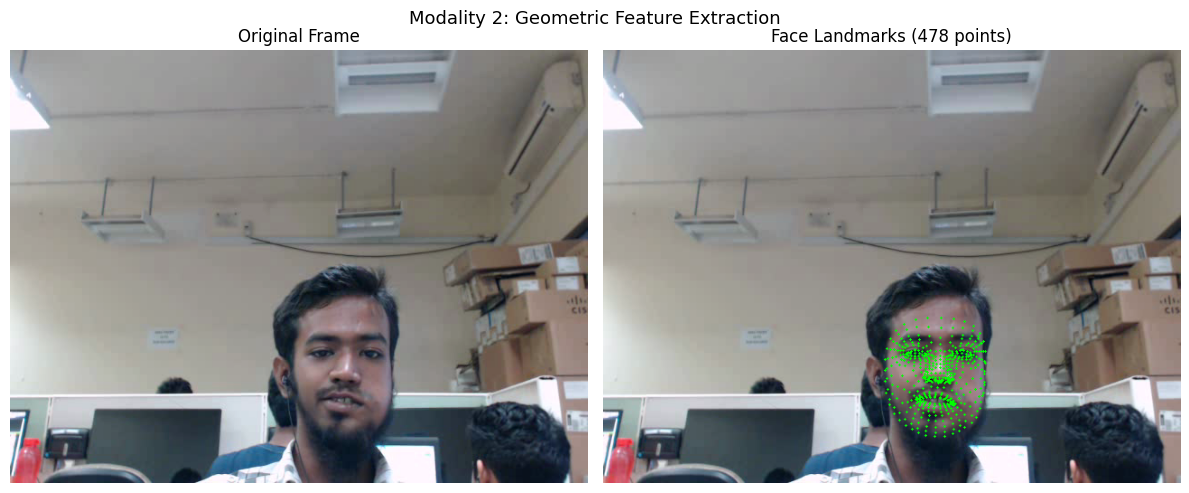

In [ ]:
if os.path.exists(sample_video) and MEDIAPIPE_TASKS and face_landmarker is not None:
    sample_frame = frames[0]
    rgb = cv2.cvtColor(sample_frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = face_landmarker.detect(mp_image)
    
    if result.face_landmarks:
        annotated = rgb.copy()
        landmarks = result.face_landmarks[0]
        h, w, _ = annotated.shape
        
        # Draw landmarks as small circles
        for lm in landmarks:
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated, (cx, cy), 1, (0, 255, 0), -1)
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        ax1.imshow(rgb)
        ax1.set_title("Original Frame")
        ax1.axis("off")
        ax2.imshow(annotated)
        ax2.set_title(f"Face Landmarks ({len(landmarks)} points)")
        ax2.axis("off")
        plt.suptitle("Modality 2: Geometric Feature Extraction", fontsize=13)
        plt.tight_layout()
        plt.savefig("face_mesh_demo.png", dpi=150, bbox_inches="tight")
        plt.show()
elif os.path.exists(sample_video):
    print("Landmark visualization skipped (MediaPipe tasks API not available).")
    print("Face detection + cropping (Modality 1) still works via OpenCV.")

 ## 8. Full Preprocessing Pipeline (Single Video)

 Putting it all together: extract both modalities from one video.

In [ ]:
def preprocess_video(video_path, num_frames=10, fd=None, fl=None):
    """
    Full preprocessing pipeline for a single video.
    
    Args:
        video_path: Path to the .avi file
        num_frames: Frames to sample
        fd: Face detector (MediaPipe tasks) or None
        fl: Face landmarker (MediaPipe tasks) or None
    
    Returns:
        appearance_data: numpy array of face crops, shape (T, 224, 224, 3)
        geometric_data: numpy array of geometric features per frame, shape (T, 6)
        metadata: dict with video info and detection stats
    """
    frames, meta = extract_frames(video_path, num_frames)
    
    if not frames:
        return None, None, meta
    
    appearance_crops = []
    geometric_features = []
    face_detected = 0
    
    for frame in frames:
        # Modality 1: Appearance
        crop, bbox = detect_and_crop_face(frame, _mp_detector=fd)
        if crop is not None:
            appearance_crops.append(crop)
            face_detected += 1
        else:
            appearance_crops.append(np.zeros((224, 224, 3), dtype=np.uint8))
        
        # Modality 2: Geometric
        geom = extract_geometric_features(frame, fl)
        if geom and geom["head_pose"] is not None:
            feat_vec = [
                geom["head_pose"][0],
                geom["head_pose"][1],
                geom["head_pose"][2],
                geom["left_ear"],
                geom["right_ear"],
                geom["mar"]
            ]
        else:
            feat_vec = [0.0] * 6
        geometric_features.append(feat_vec)
    
    appearance_data = np.array(appearance_crops)    # (T, 224, 224, 3)
    geometric_data = np.array(geometric_features)   # (T, 6)
    
    meta["face_detection_rate"] = face_detected / len(frames) if frames else 0
    
    return appearance_data, geometric_data, meta
 
 
# Demo: full pipeline on one video
if os.path.exists(sample_video):
    app_data, geom_data, video_meta = preprocess_video(
        sample_video, num_frames=10, fd=face_detector, fl=face_landmarker
    )
    
    print("=== Preprocessing Results ===")
    print(f"Appearance data shape: {app_data.shape}")
    print(f"Geometric data shape:  {geom_data.shape}")
    print(f"Face detection rate:   {video_meta['face_detection_rate']:.0%}")
    print(f"\nGeometric feature columns: [pitch, yaw, roll, left_EAR, right_EAR, MAR]")
    print(f"Sample geometric vector (frame 1): {geom_data[0]}")

=== Preprocessing Results ===
Appearance data shape: (10, 224, 224, 3)
Geometric data shape:  (10, 6)
Face detection rate:   100%

Geometric feature columns: [pitch, yaw, roll, left_EAR, right_EAR, MAR]
Sample geometric vector (frame 1): [165.74200052   1.06226315   3.49922586   0.29294174   0.23930691
   0.46851675]


 ## 9. Batch Processing Overview

 For the full dataset, we would run the pipeline on all videos and
 save the extracted features. Here we show the logic (not running
 on all 9068 videos for time reasons).

In [ ]:
def process_split(label_df, data_dir, split_name, num_frames=10, max_videos=None,
                  fd=None, fl=None):
    """
    Process all videos in a split and collect features.
    """
    all_appearance = []
    all_geometric = []
    valid_indices = []
    failed = 0
    
    n = len(label_df) if max_videos is None else min(max_videos, len(label_df))
    
    for i in range(n):
        row = label_df.iloc[i]
        video_path = get_video_path(row["ClipID"], data_dir, split=split_name)
        
        if not os.path.exists(video_path):
            failed += 1
            continue
        
        app, geom, meta = preprocess_video(video_path, num_frames, fd=fd, fl=fl)
        
        if app is not None:
            all_appearance.append(app)
            all_geometric.append(geom)
            valid_indices.append(i)
        else:
            failed += 1
        
        if (i + 1) % 50 == 0:
            print(f"  Processed {i+1}/{n} videos...")
    
    stats = {
        "total_attempted": n,
        "successful": len(valid_indices),
        "failed": failed
    }
    
    return all_appearance, all_geometric, label_df.iloc[valid_indices], stats
 
 
# Demo: process a small batch (5 videos) to verify the pipeline works
if os.path.exists(os.path.join(DATA_DIR, "Train")):
    print("Processing a small batch of 5 training videos...\n")
    app_list, geom_list, batch_labels, batch_stats = process_split(
        train_labels, DATA_DIR, "Train", num_frames=10, max_videos=5,
        fd=face_detector, fl=face_landmarker
    )
    
    print(f"\n=== Batch Processing Stats ===")
    print(f"Attempted: {batch_stats['total_attempted']}")
    print(f"Successful: {batch_stats['successful']}")
    print(f"Failed: {batch_stats['failed']}")
    
    if app_list:
        print(f"\nAppearance batch shape: ({len(app_list)}, {app_list[0].shape})")
        print(f"Geometric batch shape:  ({len(geom_list)}, {geom_list[0].shape})")
        
        print(f"\nLabels for processed batch:")
        print(batch_labels[["ClipID"] + affective_states].to_string(index=False))
else:
    print("Train data directory not found. Skipping batch demo.")

Processing a small batch of 5 training videos...


=== Batch Processing Stats ===
Attempted: 5
Successful: 5
Failed: 0

Appearance batch shape: (5, (10, 224, 224, 3))
Geometric batch shape:  (5, (10, 6))

Labels for processed batch:
        ClipID  Boredom  Engagement  Confusion  Frustration 
1100011002.avi        0           2          0             0
1100011003.avi        0           2          0             0
1100011004.avi        0           3          0             0
1100011005.avi        0           3          0             0
1100011006.avi        0           3          0             0


 ## 10.  Next Steps

 ### Plan for next two weeks:
 - **Week 1**: Run full preprocessing on all 9,068 videos; save features
   to disk as .npy files. Implement CNN backbone (ResNet-18) for appearance
   embeddings. Build PyTorch Dataset/DataLoader classes.
 - **Week 2**: Train unimodal baselines (appearance-only and geometric-only
   classifiers). Evaluate with accuracy, F1-score, and confusion matrices.
   Begin implementing early fusion.

In [ ]:
# Cleanup
if face_detector is not None and MEDIAPIPE_TASKS:
    face_detector.close()
if face_landmarker is not None and MEDIAPIPE_TASKS:
    face_landmarker.close()
 
print("Check-In 1 preprocessing pipeline complete.")

Check-In 1 preprocessing pipeline complete.
